## Polynomial features 

In [1]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

### 1 feature, degree 2

In [2]:

X = np.array([[2],[3],[4]])
print("Original X:", X)

Original X: [[2]
 [3]
 [4]]


In [3]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
print("After PolynomialFeatures", X_poly)

After PolynomialFeatures [[ 2.  4.]
 [ 3.  9.]
 [ 4. 16.]]


In [4]:
print("Feature names:", poly.get_feature_names_out(['X']))

Feature names: ['X' 'X^2']


## Complete Code 

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [6]:
# generate curved data
np.random.seed(42)
X = np.linspace(-3,3, 100).reshape(-1,1)
y = 2*X.ravel()**2 - 3*X.ravel() + 1 + np.random.randn(100)*2

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [10]:
# linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)
r2_lr = r2_score(y_test, lr.predict(X_test))
print(r2_lr)


0.571831919972557


In [9]:
# polynomial regression
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)   # fit on train only!

X_test_poly  = poly.transform(X_test)

pr = LinearRegression()
pr.fit(X_train_poly, y_train)
r2_poly = r2_score(y_test, pr.predict(X_test_poly))

print(f"Linear Regression R²     : {r2_lr:}")
print(f"Polynomial (degree=2) R² : {r2_poly:}")



Linear Regression R²     : 0.571831919972557
Polynomial (degree=2) R² : 0.9646808894337587


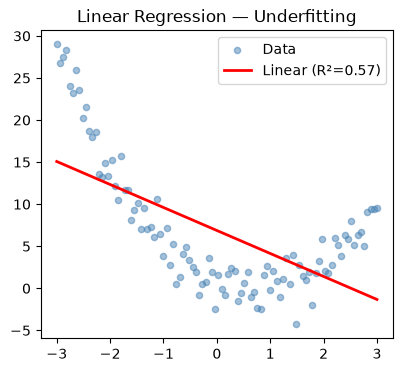

In [11]:
# ── PLOT ────────────────────────────────────────────────
X_plot = np.linspace(-3, 3, 300).reshape(-1, 1)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(X, y, alpha=0.5, s=20, color="steelblue", label="Data")
plt.plot(X_plot, lr.predict(X_plot), color="red", lw=2,
         label=f"Linear (R²={r2_lr:.2f})")
plt.title("Linear Regression — Underfitting")
plt.legend()

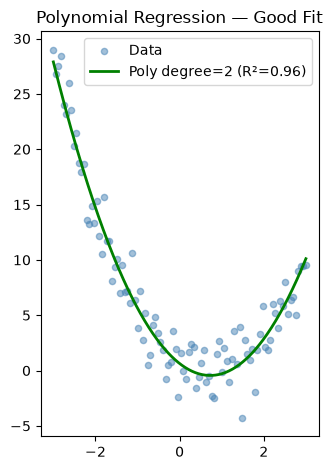

In [12]:
plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.5, s=20, color="steelblue", label="Data")
plt.plot(X_plot, pr.predict(poly.transform(X_plot)), color="green", lw=2,
         label=f"Poly degree=2 (R²={r2_poly:.2f})")
plt.title("Polynomial Regression — Good Fit")
plt.legend()

plt.tight_layout()
plt.show()
